## Práctica 5: Análisis frecuencial

Daniel Iván Lozano Simanca<br>
Samuel Ochoa Alzate

En la siguiente practica hacemos uso de las herramientas en las correspondientes librerías de Python para la creación, manejo, filtrado y análisis en frecuencia de diferentes señales. Se trabajó en esta práctica con señales generadas por numpy y a lo último, se utilizaron señales existentes en archivos .mat. Debido a que en el proyecto previo perteneciente a la práctica 3, no se encontró algún canal con diferencias relevantes, se optó por la evaluación de 2 canales aleatorios. 

Para 4.1, se definió la frecuencia de muestreo utilizando el teorema de Nyquist, utilizando nuestra frecuencia máxima como 160 Hz. Además, por el MCD, se definió el periodo de la señal generada como 1/40 s.

81


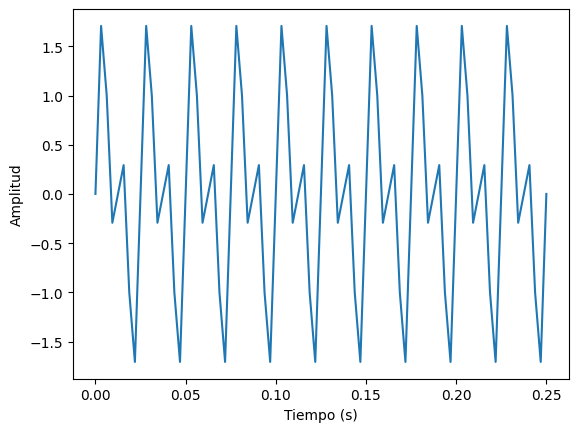

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

f1 = 40 #Hz
f2 = 80 #Hz
f3 = 160 #Hz

T = 1/40 #s
f_sampling = 1*160*2 #Hz
n = T/(1/f_sampling) #samples

tf = 10*T #s

t = np.arange(0, tf + 1/f_sampling, 1/f_sampling)

print(len(t))
signal = np.sin(2*np.pi*f1*t) + np.sin(2*np.pi*f2*t) + np.sin(2*np.pi*f3*t)
plt.plot(t, signal)
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.show()

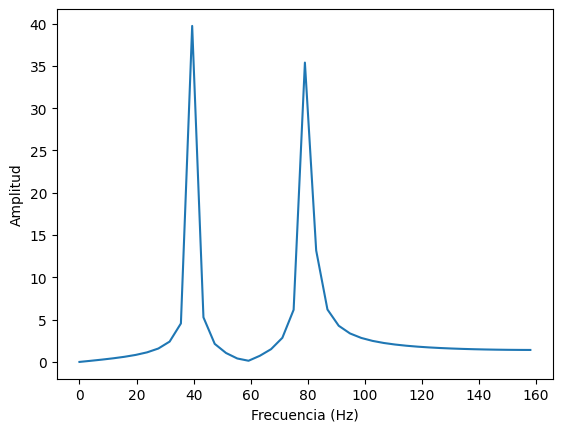

Picos en [39.50617284 79.01234568] [Hz]


In [3]:
signal_fft = np.fft.fft(signal)
n_mitad = int(np.ceil(len(signal_fft)/2))
freq_mitad = np.arange(0, n_mitad) * f_sampling / len(signal_fft)
signalfft_mitad = signal_fft[0:n_mitad]

plt.plot(freq_mitad, abs(signalfft_mitad))
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Amplitud')
plt.show()

peaks, _ = find_peaks(abs(signalfft_mitad))
x_peaks = freq_mitad[peaks]

print(f'Picos en {x_peaks} [Hz]')

Para 4.3, se utilizó la función ifft() del mismo método de la clase fft de numpy. Podemos observar que la señal reconstruida a partir de la FFT es exactamente igual.

c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


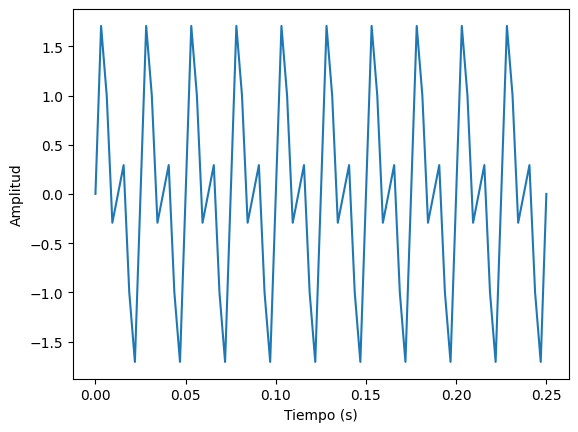

In [4]:
#IFFT
signal_ifft = np.fft.ifft(signal_fft)
plt.plot(t, signal_ifft)
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.show()

En 4.4, se utilizó el código base adquirido desde el PDF de Práctica 5. En este se nota que se hace un filtrado en la señal a través de manipular los valores en los respectivos índices de la señal de la FFT obtenida, por medio de asignar a un vector original de ceros, los valores de la transformada en la banda especificada. Así mismo, se obtiene un filtro Band-Pass, donde todos los valores de amplitud del espectro serán nulos excepto en el rango especificado.

C:\Users\ASUS\AppData\Local\Temp\ipykernel_33044\3791363391.py:4: ComplexWarning: Casting complex values to real discards the imaginary part
  F2[9:13] = F1[9:13]


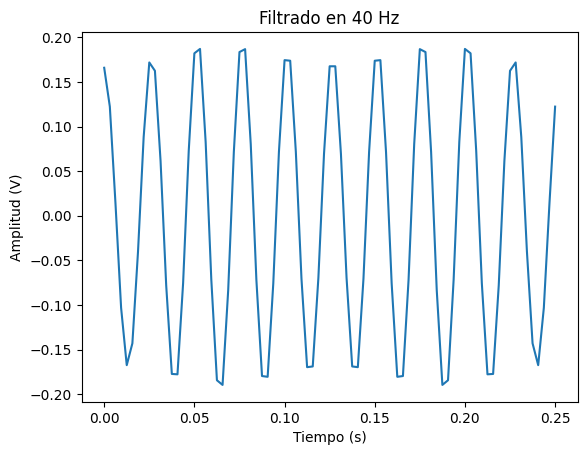

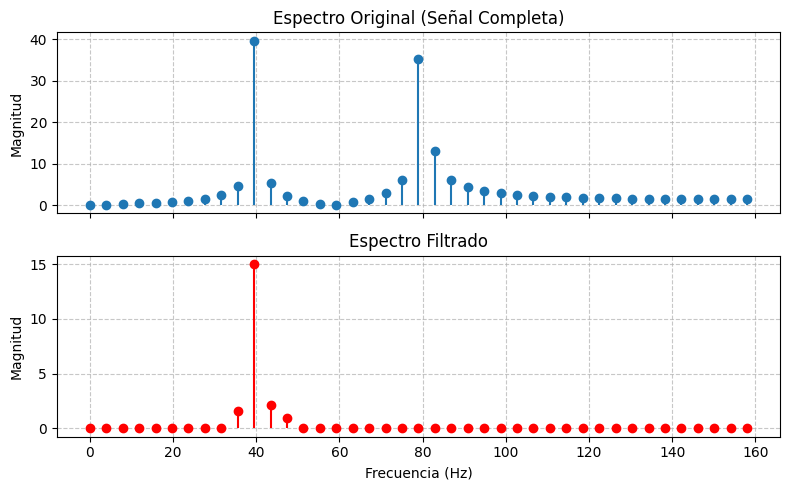

In [5]:
#Filtrando en 40Hz
F1 = np.fft.fft(signal)
F2 = np.zeros((len(F1)))
F2[9:13] = F1[9:13]
signal_r = np.fft.ifft(F2)
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(t, np.real(signal_r))
ax.set(title='Filtrado en 40 Hz',xlabel='Tiempo (s)', ylabel='Amplitud (V)')
plt.show()

F2_mitad = F2[0:n_mitad]

fig_spec, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(8, 5), sharex=True)

# Original
ax_top.stem(freq_mitad, np.abs(signalfft_mitad), basefmt=" ")
ax_top.set_title('Espectro Original (Señal Completa)')
ax_top.set_ylabel('Magnitud')
ax_top.grid(True, linestyle='--', alpha=0.7)

# Filtrada
ax_bot.stem(freq_mitad, np.abs(F2_mitad), linefmt='r', markerfmt='ro', basefmt=" ")
ax_bot.set_title('Espectro Filtrado')
ax_bot.set_xlabel('Frecuencia (Hz)')
ax_bot.set_ylabel('Magnitud')
ax_bot.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Podemos ver que a la señal se le aplicó un filtro Band-Pass centrado en ~ 40 Hz.

C:\Users\ASUS\AppData\Local\Temp\ipykernel_34532\2411196607.py:4: ComplexWarning: Casting complex values to real discards the imaginary part
  F_80[19:23] = F1[19:23]


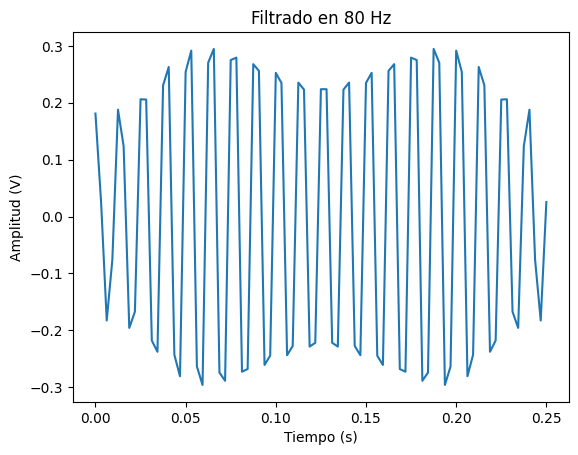

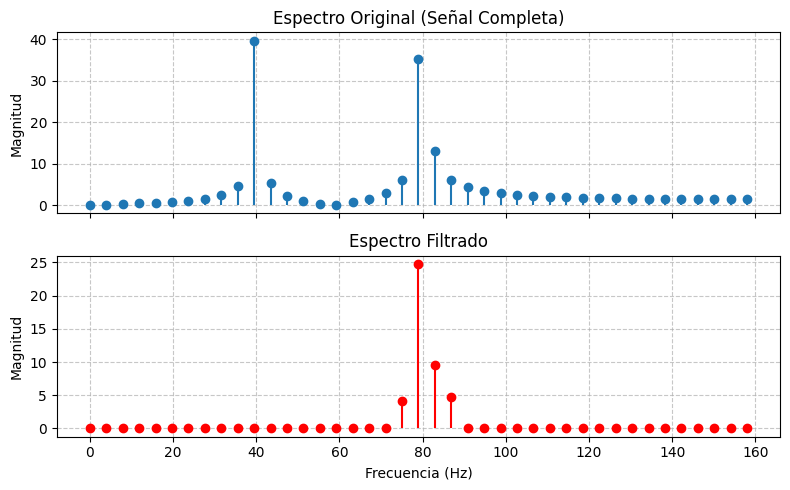

In [12]:
#Filtrando en 80Hz
#F1 = np.fft.fft(signal)
F_80 = np.zeros((len(F1)))
F_80[19:23] = F1[19:23]
signal_80 = np.fft.ifft(F_80)

fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(t, np.real(signal_80))
ax.set(title='Filtrado en 80 Hz', xlabel='Tiempo (s)', ylabel='Amplitud (V)')
plt.show()

F_80_mitad = F_80[0:n_mitad]
fig_spec, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(8, 5), sharex=True)

# Original
ax_top.stem(freq_mitad, np.abs(signalfft_mitad), basefmt=" ")
ax_top.set_title('Espectro Original (Señal Completa)')
ax_top.set_ylabel('Magnitud')
ax_top.grid(True, linestyle='--', alpha=0.7)

# Filtrada
ax_bot.stem(freq_mitad, np.abs(F_80_mitad), linefmt='r', markerfmt='ro', basefmt=" ")
ax_bot.set_title('Espectro Filtrado')
ax_bot.set_xlabel('Frecuencia (Hz)')
ax_bot.set_ylabel('Magnitud')
ax_bot.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_33044\3073870752.py:4: ComplexWarning: Casting complex values to real discards the imaginary part
  F_160[39:43] = F1[39:43]


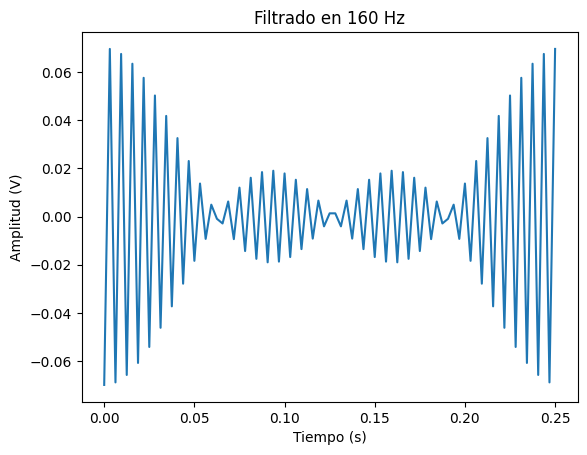

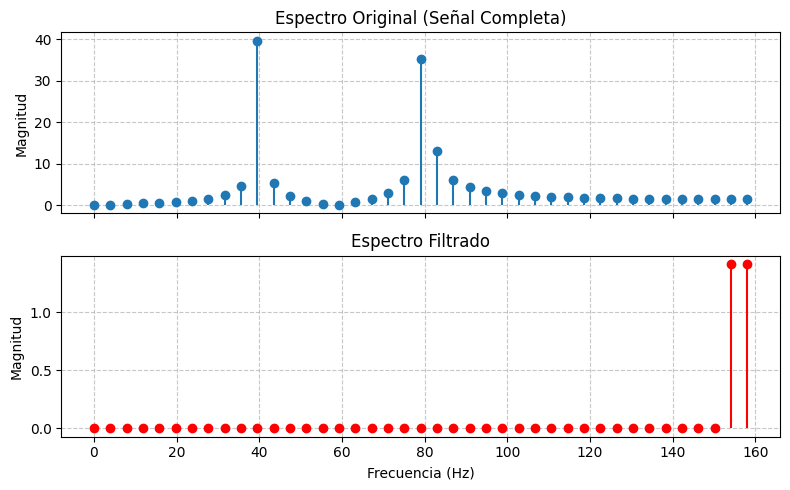

In [6]:
#Filtrando en 160Hz
#F1 = np.fft.fft(signal)
F_160 = np.zeros((len(F1)))
F_160[39:43] = F1[39:43]
signal_160 = np.fft.ifft(F_160)

fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(t, np.real(signal_160))
ax.set(title='Filtrado en 160 Hz', xlabel='Tiempo (s)', ylabel='Amplitud (V)')
plt.show()

F_160_mitad = F_160[0:n_mitad]
fig_spec, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(8, 5), sharex=True)

# Original
ax_top.stem(freq_mitad, np.abs(signalfft_mitad), basefmt=" ")
ax_top.set_title('Espectro Original (Señal Completa)')
ax_top.set_ylabel('Magnitud')
ax_top.grid(True, linestyle='--', alpha=0.7)

# Filtrada
ax_bot.stem(freq_mitad, np.abs(F_160_mitad), linefmt='r', markerfmt='ro', basefmt=" ")
ax_bot.set_title('Espectro Filtrado')
ax_bot.set_xlabel('Frecuencia (Hz)')
ax_bot.set_ylabel('Magnitud')
ax_bot.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Para 4.5, se trabajará con un archivo .mat en el cual vamos a extraer una señal de ECG. EL objetivo de este apartado será realizar el respectivo análisis en frecuencia por medio del método de Welch; a la vez que, a partir de este, realizar un filtrado del ruido de la señal [1].

Se escogió un ancho de ventana de 500 muestras. Debido a que se tiene que la frecuencia de muestreo (fs) es de 250 Hz, una ventana de esa cantidad equivaldría a 2 segundos de la señal. Ese es un tiempo ideal para el ECG ya que garantiza que en cada ventana tengamos al menos 2 ciclos cardíacos completos. Asimismo, este ancho de ventana proporciona una resolución espectral de 0.5 Hz ($\Delta f = f_s / nperseg$), lo que resulta adecuado para discriminar frecuencias fisiológicas de artefactos de baja frecuencia [3]. Para el solapamiento, se decidió por un 50% de la ventana, debido a que se busca minimizar el solapamiento de los bordes en cada ventana, lo cual se hace de forma que cada borde coincida con un punto central de la siguiente [1], [4]. 

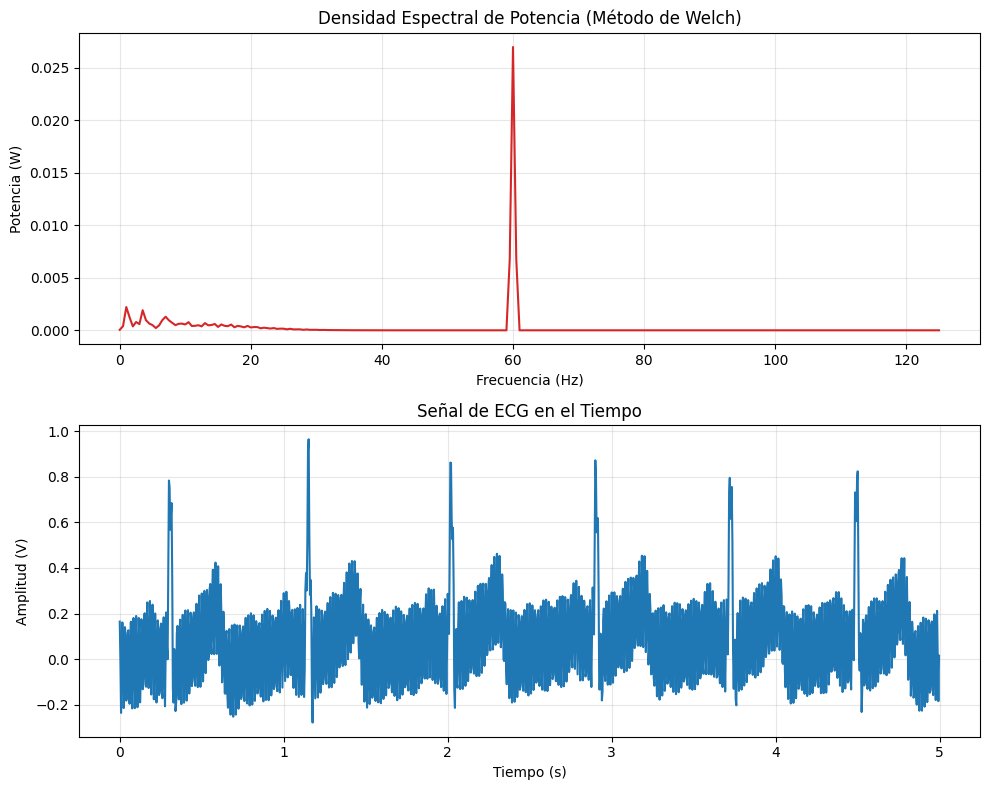

In [7]:
from scipy.io import loadmat
from scipy.signal import welch 

data = loadmat('senecg.mat')
signal_ecg = data['ECG'].flatten()

fs = 250 #Hz

t = np.arange(0, len(signal_ecg)/fs, 1/fs)
n_ventana = 500 #num de muestras para la ventana
n_overlap = int(n_ventana/2)
freqs, Pxx = welch(signal_ecg, 
                   fs=fs, 
                   window='hann', 
                   nperseg=n_ventana, 
                   noverlap=n_overlap)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))


ax1.plot(freqs, Pxx, color='tab:red')
ax1.set_title('Densidad Espectral de Potencia (Método de Welch)')
ax1.set_xlabel('Frecuencia (Hz)')
ax1.set_ylabel('Potencia (W)')
ax1.grid(True, alpha=0.3)

ax2.plot(t, signal_ecg, color='tab:blue')
ax2.set_title('Señal de ECG en el Tiempo')
ax2.set_xlabel('Tiempo (s)')
ax2.set_ylabel('Amplitud (V)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



In [8]:
trans_ecg = np.fft.fft(signal_ecg)

n_mitadECG = int(np.ceil(len(trans_ecg)/2))
freq_mitad = np.arange(0, n_mitadECG) * fs / len(trans_ecg)
transECG_mitad = trans_ecg[0:n_mitadECG]

peaks, _ = find_peaks(abs(transECG_mitad), height=40)
x_peaks = freq_mitad[peaks]

print(f'Picos en {x_peaks} [Hz]')
print(peaks)

Picos en [60.] [Hz]
[300]


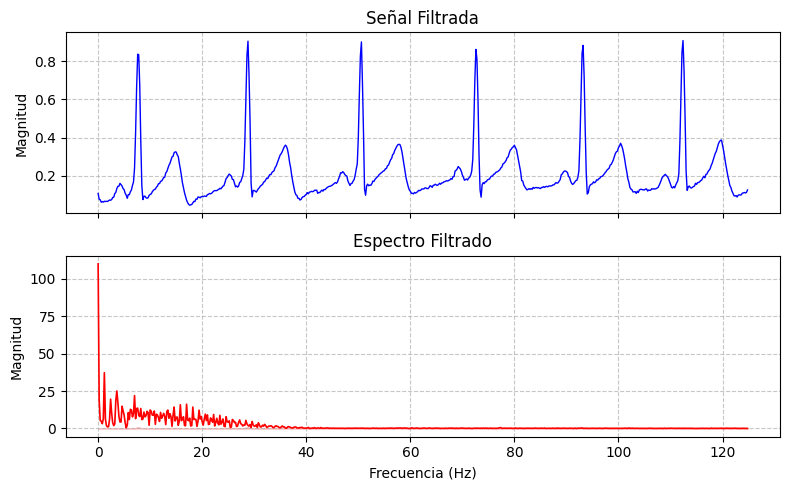

In [9]:
#Filtrando en 40Hz
signalZeros = np.zeros((len(transECG_mitad)))
#signalZeros[9:13] = transECG_mitad[9:13]
transECG_mitad[299:301] = signalZeros[299:301]
signalECG_r = np.fft.ifft(transECG_mitad)

fig_spec, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(8, 5), sharex=True)

#LA señal filtrada en 60 Hz
ax_top.plot(freq_mitad, np.abs(signalECG_r), color='blue', linewidth=1)
ax_top.set_title('Señal Filtrada')
ax_top.set_ylabel('Magnitud')
ax_top.grid(True, linestyle='--', alpha=0.7)

#Espectro de la señal filtrada
ax_bot.plot(freq_mitad, np.abs(transECG_mitad), color='red', linewidth=1.2)
ax_bot.set_title('Espectro Filtrado')
ax_bot.set_xlabel('Frecuencia (Hz)')
ax_bot.set_ylabel('Magnitud')
ax_bot.grid(True, linestyle='--', alpha=0.7)

ax_bot.fill_between(freq_mitad, np.abs(signalECG_r), color='red', alpha=0.2)

plt.tight_layout()
plt.show()

Finalmente para 4.6 se hace uso de los datos en los grupos de control y parkinson usados y comparados en prac3. Debido a lo explicado al inicio, de no haber encontrado canales con diferencias relevantes, se procede a cargar la información de todos los canales en 2 sujetos cualquiera, siendo 1 por cada grupo. Posteriormente, por una semilla random de rand, con fines de reproducibilidad y repetibilidad, se escogen 2 canales aleatorios en los que se hace el anális comparativo de las señales en el tiempo y en su espectro de frecuencias. 

In [10]:
import pandas as pd
import os
import scipy.io as sio


def cargar_señales(carpeta):
    signals = {}
    for archivo in sorted(os.listdir(carpeta)):
        if archivo.endswith('.mat'):
            sujeto = archivo.replace('_EP_reposo.mat', '')
            ruta   = os.path.join(carpeta, archivo)
            data   = sio.loadmat(ruta)['data']
            signals[sujeto] = data
    return signals

signals_control   = cargar_señales('control')
signals_parkinson = cargar_señales('parkinson')

Fs = 250
nombres_canales = ['F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2']

print(f"Sujetos control:   {list(signals_control.keys())}")
print(f"Sujetos Parkinson: {list(signals_parkinson.keys())}")


Sujetos control:   ['C001R', 'C002', 'C004', 'C005_EP_reposo_Repetido.mat', 'C006', 'C007', 'C010', 'C011', 'C012', 'C013', 'C015', 'C018', 'C019', 'C020', 'C021', 'C023', 'C024', 'C025', 'C026', 'C027', 'C028', 'C029', 'C030', 'C031', 'C032', 'C033R', 'C034', 'C036', 'C037', 'C040', 'C041', 'C042', 'C044', 'C045', 'C046', 'C049']
Sujetos Parkinson: ['P001', 'P004', 'P005', 'P007', 'P012', 'P013', 'P015', 'P016', 'P017', 'P018', 'P020', 'P025', 'P026', 'P028', 'P030', 'P032', 'P033', 'P034', 'P040', 'P041', 'P046', 'P048', 'P049']


In [45]:
#Usamos 2 canales random

np.random.seed(42)  #para reproducibilidad
indices_seleccionados = np.random.choice(len(nombres_canales), size=2, replace=False)
canales_seleccionados = [nombres_canales[i] for i in indices_seleccionados]

print(f"Canales seleccionados al azar: {canales_seleccionados}")

nperseg  = 256
noverlap = nperseg // 2

bandas = {
    'Delta\n(0-4 Hz)':   (0,   4),
    'Theta\n(4-8 Hz)':   (4,   8),
    'Alpha\n(8-13 Hz)':  (8,  13),
    'Beta\n(13-30 Hz)':  (13, 30),
    'Gamma\n(30-45 Hz)': (30, 45),
}
colores_banda = ['#d4e6f1', '#d5f5e3', '#fdebd0', '#f9ebea', '#e8daef']


def psd_grupo(señales_dict, canal_idx, Fs, nperseg, noverlap):
    psds_sujetos = []
    for sujeto, data in señales_dict.items():
        n_epocas = data.shape[2]
        psds_epocas = []
        for ep in range(n_epocas):
            f, Pxx = welch(data[canal_idx, :, ep], fs=Fs,
                           window='hann', nperseg=nperseg, noverlap=noverlap)
            psds_epocas.append(Pxx)
        psds_sujetos.append(np.mean(psds_epocas, axis=0))
    psds_sujetos = np.array(psds_sujetos)
    return f, np.mean(psds_sujetos, axis=0), np.std(psds_sujetos, axis=0)

Canales seleccionados al azar: ['F4', 'P4']


In [46]:
resultados = {}
for i, canal in zip(indices_seleccionados, canales_seleccionados):
    f, psd_ctrl_m, psd_ctrl_s = psd_grupo(signals_control,   i, Fs, nperseg, noverlap)
    _, psd_park_m, psd_park_s = psd_grupo(signals_parkinson, i, Fs, nperseg, noverlap)
    resultados[canal] = {
        'f':          f,
        'ctrl_media': psd_ctrl_m, 'ctrl_std': psd_ctrl_s,
        'park_media': psd_park_m, 'park_std': psd_park_s,
    }

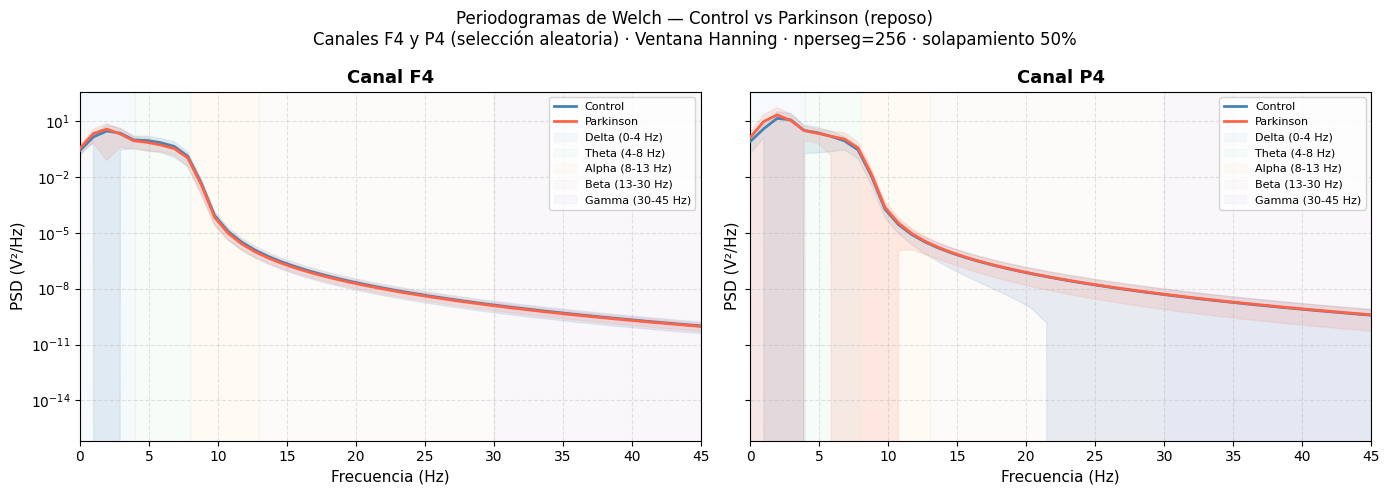

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, canal in zip(axes, canales_seleccionados):
    res = resultados[canal]
    f   = res['f']

    ax.semilogy(f, res['ctrl_media'], color='steelblue',
                linewidth=2, label='Control', zorder=3)
    ax.fill_between(f,
                    res['ctrl_media'] - res['ctrl_std'],
                    res['ctrl_media'] + res['ctrl_std'],
                    color='steelblue', alpha=0.15)

    ax.semilogy(f, res['park_media'], color='tomato',
                linewidth=2, label='Parkinson', zorder=3)
    ax.fill_between(f,
                    res['park_media'] - res['park_std'],
                    res['park_media'] + res['park_std'],
                    color='tomato', alpha=0.15)

    for (nb, (lo, hi)), cb in zip(bandas.items(), colores_banda):
        ax.axvspan(lo, hi, alpha=0.2, color=cb, label=nb.replace('\n', ' '))

    ax.set_xlim(0, 45)
    ax.set_title(f'Canal {canal}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Frecuencia (Hz)', fontsize=11)
    ax.set_ylabel('PSD (V²/Hz)', fontsize=11)
    ax.grid(True, which='both', linestyle='--', alpha=0.35)
    ax.legend(fontsize=8, loc='upper right')

fig.suptitle('Periodogramas de Welch — Control vs Parkinson (reposo)\n'
             f'Canales {canales_seleccionados[0]} y {canales_seleccionados[1]} '
             f'(selección aleatoria) · Ventana Hanning · '
             f'nperseg={nperseg} · solapamiento 50%',
             fontsize=12)
plt.tight_layout()
plt.show()

In [48]:
def potencia_banda(f, Pxx, f_lo, f_hi):
    mask = (f >= f_lo) & (f <= f_hi)
    return np.trapezoid(Pxx[mask], f[mask])

filas = []
for canal in canales_seleccionados:
    res = resultados[canal]
    for nb, (lo, hi) in bandas.items():
        nb_limpio = nb.replace('\n', ' ')
        p_c = potencia_banda(res['f'], res['ctrl_media'], lo, hi)
        p_p = potencia_banda(res['f'], res['park_media'], lo, hi)
        diff = (p_p - p_c) / p_c * 100
        filas.append({
            'Canal': canal, 'Banda': nb_limpio,
            'Control (V²)': f'{p_c:.4e}',
            'Parkinson (V²)': f'{p_p:.4e}',
            'Δ%': f'{diff:+.1f}%',
            'Tendencia': 'Positiv. Park' if diff > 15 else ('Neg. Park' if diff < -15 else '≈')
        })

df_potencias = pd.DataFrame(filas)
print("\nPOTENCIA POR BANDA — Control vs Parkinson")
print(df_potencias.to_string(index=False))


POTENCIA POR BANDA — Control vs Parkinson
Canal            Banda Control (V²) Parkinson (V²)     Δ%     Tendencia
   F4   Delta (0-4 Hz)   7.0601e+00     8.3372e+00 +18.1% Positiv. Park
   F4   Theta (4-8 Hz)   1.5984e+00     1.2408e+00 -22.4%     Neg. Park
   F4  Alpha (8-13 Hz)   2.3763e-03     1.9626e-03 -17.4%     Neg. Park
   F4  Beta (13-30 Hz)   9.2668e-07     7.8767e-07 -15.0%     Neg. Park
   F4 Gamma (30-45 Hz)   6.1401e-09     5.6681e-09  -7.7%             ≈
   P4   Delta (0-4 Hz)   3.1020e+01     4.3241e+01 +39.4% Positiv. Park
   P4   Theta (4-8 Hz)   3.6331e+00     3.8253e+00  +5.3%             ≈
   P4  Alpha (8-13 Hz)   5.6563e-03     7.0409e-03 +24.5% Positiv. Park
   P4  Beta (13-30 Hz)   2.8399e-06     3.0087e-06  +5.9%             ≈
   P4 Gamma (30-45 Hz)   2.2660e-08     2.3775e-08  +4.9%             ≈


## Análisis de resultados



## Referencias

[1] P. Welch, "The use of fast Fourier transform for the estimation of power spectra: A method based on time averaging over short, modified periodograms," IEEE Transactions on Audio and Electroacoustics, vol. 15, no. 2, pp. 70–73, Jun. 1967.

[2] Task Force of the European Society of Cardiology and the North American Society of Pacing and Electrophysiology, "Heart rate variability: Standards of measurement, physiological interpretation, and clinical use," Circulation, vol. 93, no. 5, pp. 1043–1065, Mar. 1996.  

[3] J. G. Proakis and D. G. Manolakis, Digital Signal Processing: Principles, Algorithms, and Applications, 4th ed. Upper Saddle River, NJ, USA: Prentice-Hall, 2007.

[4] A. V. Oppenheim and R. W. Schafer, Discrete-Time Signal Processing, 3rd ed. Upper Saddle River, NJ, USA: Prentice-Hall, 2009.